In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import  GridSearchCV, KFold

In [4]:
import xgboost as xgb

In [5]:
data = pd.read_csv('sleeptime_prediction_dataset.csv')
data.head()

,WorkoutTime,ReadingTime,PhoneTime,WorkHours,CaffeineIntake,RelaxationTime,SleepTime
0,1.12,0.52,3.29,7.89,216.08,0.75,3.45
1,2.85,0.49,4.22,5.03,206.18,0.67,4.88
2,2.20,1.81,4.04,9.23,28.73,0.35,3.61
3,1.80,0.50,1.62,7.68,276.77,1.21,4.94
4,0.47,0.54,1.60,4.94,170.54,0.95,5.50


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   WorkoutTime     2000 non-null   float64
 1   ReadingTime     2000 non-null   float64
 2   PhoneTime       2000 non-null   float64
 3   WorkHours       2000 non-null   float64
 4   CaffeineIntake  2000 non-null   float64
 5   RelaxationTime  2000 non-null   float64
 6   SleepTime       2000 non-null   float64
dtypes: float64(7)
memory usage: 109.5 KB


In [7]:
data.describe()

,WorkoutTime,ReadingTime,PhoneTime,WorkHours,CaffeineIntake,RelaxationTime,SleepTime
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1.495915,0.992785,2.985195,6.926945,147.493780,1.010955,4.884375
std,0.876639,0.577303,1.151776,1.723843,84.651139,0.582619,2.028892
min,0.010000,0.000000,1.000000,4.000000,0.020000,0.000000,0.150000
25%,0.710000,0.500000,1.990000,5.440000,75.980000,0.510000,3.840000
50%,1.520000,0.990000,2.965000,6.910000,146.010000,1.010000,4.600000
75%,2.250000,1.500000,3.960000,8.422500,218.902500,1.530000,5.470000
max,3.000000,2.000000,5.000000,10.000000,299.850000,2.000000,19.810000


In [8]:
# ReadingTime 제거
data = data.drop('ReadingTime', axis=1)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   WorkoutTime     2000 non-null   float64
 1   PhoneTime       2000 non-null   float64
 2   WorkHours       2000 non-null   float64
 3   CaffeineIntake  2000 non-null   float64
 4   RelaxationTime  2000 non-null   float64
 5   SleepTime       2000 non-null   float64
dtypes: float64(6)
memory usage: 93.9 KB


In [10]:
data.describe()

,WorkoutTime,PhoneTime,WorkHours,CaffeineIntake,RelaxationTime,SleepTime
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1.495915,2.985195,6.926945,147.493780,1.010955,4.884375
std,0.876639,1.151776,1.723843,84.651139,0.582619,2.028892
min,0.010000,1.000000,4.000000,0.020000,0.000000,0.150000
25%,0.710000,1.990000,5.440000,75.980000,0.510000,3.840000
50%,1.520000,2.965000,6.910000,146.010000,1.010000,4.600000
75%,2.250000,3.960000,8.422500,218.902500,1.530000,5.470000
max,3.000000,5.000000,10.000000,299.850000,2.000000,19.810000


In [11]:
# 모든 특성의 이상치 한번에 확인
for col in data.columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f"{col}: 이상치 {len(outliers)}개 (범위: {lower:.2f}~{upper:.2f})")

WorkoutTime: 이상치 0개 (범위: -1.60~4.56)
PhoneTime: 이상치 0개 (범위: -0.97~6.92)
WorkHours: 이상치 0개 (범위: 0.97~12.90)
CaffeineIntake: 이상치 0개 (범위: -138.40~433.29)
RelaxationTime: 이상치 0개 (범위: -1.02~3.06)
SleepTime: 이상치 64개 (범위: 1.40~7.91)


In [12]:
data_clean = data[(data['SleepTime'] >= lower) & (data['SleepTime'] <= upper)]

print(f"원본 데이터: {len(data)}개")
print(f"이상치 제거 후: {len(data_clean)}개")
print(f"제거된 이상치: {len(data) - len(data_clean)}개 (3.2%)")

원본 데이터: 2000개
이상치 제거 후: 1936개
제거된 이상치: 64개 (3.2%)


In [13]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1936 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   WorkoutTime     1936 non-null   float64
 1   PhoneTime       1936 non-null   float64
 2   WorkHours       1936 non-null   float64
 3   CaffeineIntake  1936 non-null   float64
 4   RelaxationTime  1936 non-null   float64
 5   SleepTime       1936 non-null   float64
dtypes: float64(6)
memory usage: 105.9 KB


In [14]:
data_clean.describe()

,WorkoutTime,PhoneTime,WorkHours,CaffeineIntake,RelaxationTime,SleepTime
count,1936.000000,1936.000000,1936.000000,1936.000000,1936.000000,1936.000000
mean,1.491457,2.993802,6.925744,147.536353,1.007712,4.627614
std,0.875963,1.152276,1.723857,84.292106,0.581714,1.070818
min,0.010000,1.000000,4.000000,0.020000,0.000000,1.550000
25%,0.710000,1.990000,5.440000,76.080000,0.500000,3.820000
50%,1.520000,2.990000,6.905000,146.230000,1.000000,4.560000
75%,2.240000,3.970000,8.420000,217.775000,1.520000,5.390000
max,3.000000,5.000000,10.000000,299.850000,2.000000,7.830000


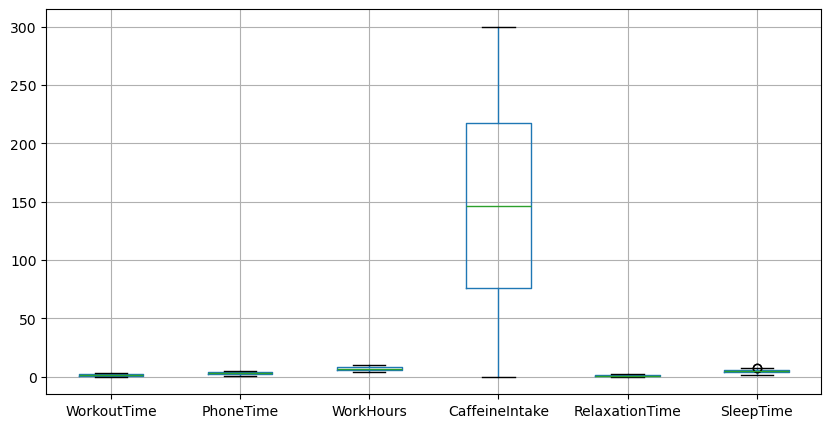

In [15]:
data_clean.boxplot(figsize=(10,5))
plt.show()

In [16]:
X = data_clean.drop('SleepTime', axis=1)
y = data_clean['SleepTime']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42)

In [18]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1355, 5), (581, 5), (1355,), (581,))

In [19]:
model = xgb.XGBRegressor()
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [20]:
model.score(X_train, y_train)

0.9990901118975148

In [21]:
model.score(X_test, y_test)

0.8785189796402271

In [22]:
# MAE 계산 (평균 절대 오차)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.2f} 시간")

MAE: 0.24 시간


In [23]:
# RMSE 계산 (평균 제곱근 오차)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f} 시간")

RMSE: 0.37 시간


In [24]:
# R² 계산
r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2:.4f}")

R2 Score: 0.8785


In [25]:
cross_val_score(model, X_train, y_train, cv = 10)

array([0.78126833, 0.82379422, 0.76941458, 0.80549252, 0.87892966,
       0.76527066, 0.89293664, 0.90605263, 0.82614692, 0.90527831])

In [26]:
grid_model = xgb.XGBRegressor(random_state=18)

params = {
    'n_estimators': [30, 50, 70, 100],        # 트리 개수
    'max_depth': [3, 4, 5, 6],                 # 트리 깊이
    'learning_rate': [0.01, 0.05, 0.1, 0.3],   # 학습률 (XGBoost 핵심!)
    'min_child_weight': [1, 3, 5, 7],          # min_samples_leaf 역할
    'subsample': [0.8, 0.9, 1.0],              # 데이터 샘플링 비율
    'colsample_bytree': [0.8, 0.9, 1.0]        # 특성 샘플링 비율
}

In [27]:
# 3. 교차검증 방식
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. GridSearch
grid = GridSearchCV(
    model,           # XGBoost 모델로 변경!
    params,
    cv=cv,
    scoring='r2',        # 회귀니까 'r2'
    n_jobs=-1,
    verbose=2
)

# 5. 학습
grid.fit(X_train, y_train)

Fitting 5 folds for each of 2304 candidates, totalling 11520 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [28]:
grid.best_params_

{'colsample_bytree': 1.0,
 'learning_rate': 0.1,
 'max_depth': 3,
 'min_child_weight': 5,
 'n_estimators': 100,
 'subsample': 0.8}

In [29]:
grid.score(X_train, y_train)

0.9213448266868027

In [30]:
grid.score(X_test, y_test)

0.9131942740976082

In [31]:
# 최적 모델로 예측
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [32]:
print(f"MAE: {mae:.3f} 시간")
print(f"RMSE: {rmse:.3f} 시간")
print(f"R2: {r2:.4f}")

MAE: 0.205 시간
RMSE: 0.312 시간
R2: 0.9132


In [33]:
def get_asymmetric_sleep_score_v2(predicted_hours):
    target = 7.5  # 목표 수면 시간
    
    # 수면 부족은 피로도, 집중력 저하, 다크서클 악화에 직접적 영향이 크므로 엄격하게 반영
    # 수면 과다(9~10시간)는 부족에 비해 건강 위험도가 상대적으로 낮고, 일시적 과수면은 회복 과정일 수 있어 관대하게 적용
    # 11시간 이상의 장시간 수면은 점차 감점하여 과수면 문제도 완전히 무시하지 않음
    
    # 감소율 조정
    sigma_before = 1.8   # 7.5시간 이전
    sigma_after = 4.2    # 7.5시간 이후
    
    # 목표 시간보다 적게 자면 (왼쪽)
    if predicted_hours <= target:
        score = 100 * np.exp(-((predicted_hours - target)**2) / (2 * (sigma_before**2)))
    # 목표 시간보다 많이 자면 (오른쪽)
    else:
        score = 100 * np.exp(-((predicted_hours - target)**2) / (2 * (sigma_after**2)))
    
    return round(score, 1)

# 다양한 수면 시간에 대한 점수 계산
sleep_times = [4, 5, 6, 7, 7.5, 8, 9, 10, 11, 12]
print("="*60)
print("조정된 비대칭 가우시안 점수 (감소율 완화)")
print("="*60)

for hours in sleep_times:
    score = get_asymmetric_sleep_score_v2(hours)
    diff = hours - 7.5
    direction = "부족" if diff < 0 else "초과" if diff > 0 else "최적"
    
    print(f"수면 {hours}시간 ({direction:>4}) → {score:>5}점")

조정된 비대칭 가우시안 점수 (감소율 완화)
수면 4시간 (  부족) →  15.1점
수면 5시간 (  부족) →  38.1점
수면 6시간 (  부족) →  70.7점
수면 7시간 (  부족) →  96.2점
수면 7.5시간 (  최적) → 100.0점
수면 8시간 (  초과) →  99.3점
수면 9시간 (  초과) →  93.8점
수면 10시간 (  초과) →  83.8점
수면 11시간 (  초과) →  70.7점
수면 12시간 (  초과) →  56.3점


In [34]:
# 한글폰트 적용
plt.rcParams['font.family'] = 'Malgun Gothic'
# 한글폰트 사용 시 마이너스 기호가 네모(ㅁ) 깨지는 현상 방지
plt.rcParams['axes.unicode_minus'] = False

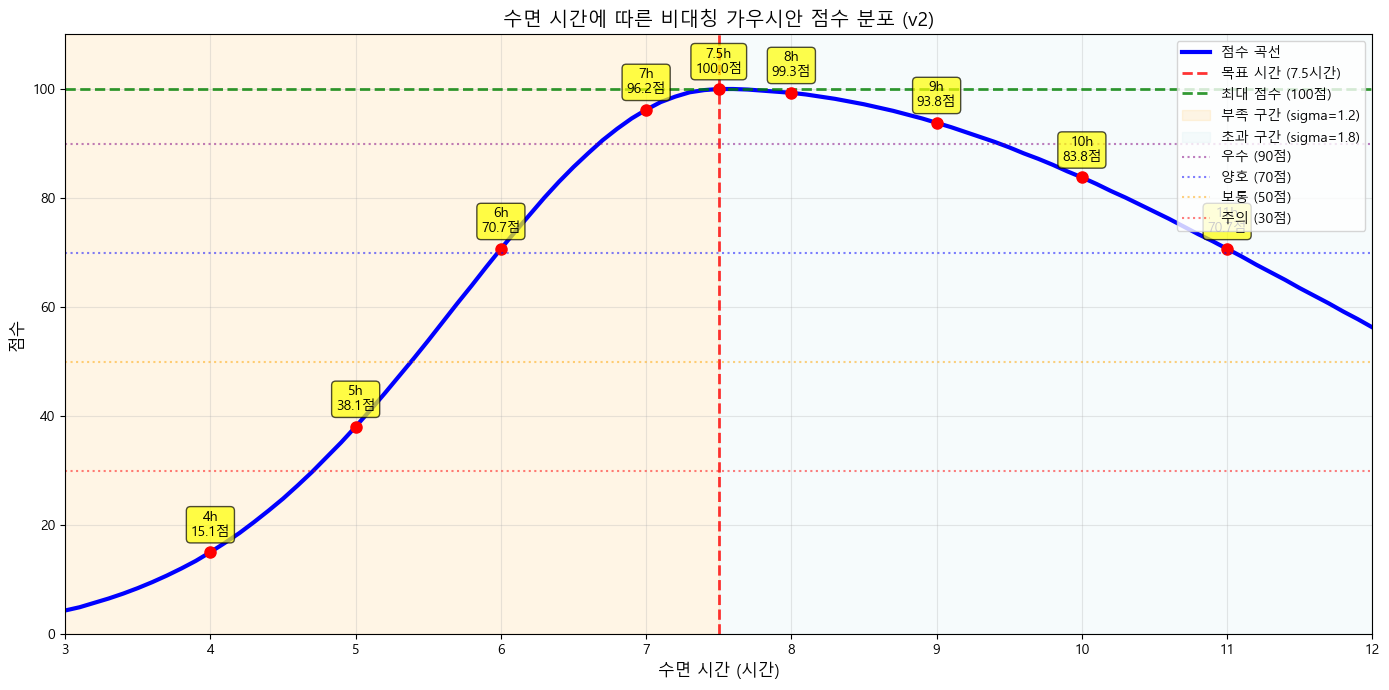

In [35]:
# 그래프
plt.figure(figsize=(14, 7))

# 점수 곡선
hours_range = np.arange(3, 13, 0.1)
scores = [get_asymmetric_sleep_score_v2(h) for h in hours_range]
plt.plot(hours_range, scores, 'b-', linewidth=3, label='점수 곡선')

# 목표 시간
plt.axvline(x=7.5, color='red', linestyle='--', linewidth=2, alpha=0.8, label='목표 시간 (7.5시간)')
plt.axhline(y=100, color='green', linestyle='--', linewidth=2, alpha=0.8, label='최대 점수 (100점)')

# 구역 색칠하기
plt.axvspan(3, 7.5, alpha=0.1, color='orange', label='부족 구간 (sigma=1.2)')
plt.axvspan(7.5, 12, alpha=0.1, color='lightblue', label='초과 구간 (sigma=1.8)')

# 주요 시간대 점수 표시
time_points = [4, 5, 6, 7, 7.5, 8, 9, 10, 11]
for hours in time_points:
    score = get_asymmetric_sleep_score_v2(hours)
    plt.plot(hours, score, 'ro', markersize=8)
    plt.text(hours, score+3, f'{hours}h\n{score}점', ha='center', fontsize=10, 
             bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# 등급 구분선
plt.axhline(y=90, color='purple', linestyle=':', alpha=0.5, label='우수 (90점)')
plt.axhline(y=70, color='blue', linestyle=':', alpha=0.5, label='양호 (70점)')
plt.axhline(y=50, color='orange', linestyle=':', alpha=0.5, label='보통 (50점)')
plt.axhline(y=30, color='red', linestyle=':', alpha=0.5, label='주의 (30점)')

plt.grid(True, alpha=0.3)
plt.xlabel('수면 시간 (시간)', fontsize=12)
plt.ylabel('점수', fontsize=12)
plt.title('수면 시간에 따른 비대칭 가우시안 점수 분포 (v2)', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.ylim(0, 110)
plt.xlim(3, 12)
plt.tight_layout()
plt.show()

In [36]:
def get_final_sleep_score(workout, phone, work_hours, caffeine, relaxation):
    """
    생활패턴 기반 최종 수면 점수 계산
    
    가중치 구성:
     - 수면예상점수: 40% (ML로 예측한 수면시간을 점수화)
     - 운동: 10% (양의 상관관계 - 적당한 운동이 수면에 도움)
     - 핸드폰: 10% (음의 상관관계 - 사용시간이 적을수록 좋음)
     - 근무: 20% (음의 상관관계 - 근무시간이 적을수록 좋음)
     - 카페인: 10% (음의 상관관계 - 섭취량이 적을수록 좋음)
     - 휴식: 10% (양의 상관관계 - 충분한 휴식이 수면에 도움)
    """
    
    # ===== 1단계: 수면시간 예측 =====
    # 입력 데이터프레임 생성
    input_data = pd.DataFrame([{
        'WorkoutTime': workout,
        'PhoneTime': phone,
        'WorkHours': work_hours,
        'CaffeineIntake': caffeine,
        'RelaxationTime': relaxation
    }])
    
    # 학습된 best_model로 예측
    prediction = best_model.predict(input_data)[0]
    
    # 소수점 1자리까지 반올림 (float로 변환 후 반올림)
    predicted_sleep = round(float(prediction), 1)
    
    # ===== 2단계: 수면예상점수 계산 (40%) =====
    # 목표 수면시간 7.5시간을 기준으로 비대칭 가우시안 분포 적용
    target = 7.5  # 최적의 수면 시간
    sigma_before = 1.8  # 목표 시간보다 적게 잘 때의 표준편차 (완만한 감소)
    sigma_after = 4.2   # 목표 시간보다 많이 잘 때의 표준편차 (매우 완만한 감소)
    
    # 목표 시간보다 적게 자는 경우 (왼쪽 꼬리)
    if predicted_sleep <= target:
        sleep_score = 100 * np.exp(-((predicted_sleep - target)**2) / (2 * (sigma_before**2)))
    # 목표 시간보다 많이 자는 경우 (오른쪽 꼬리) - 과다 수면은 덜 패널티
    else:
        sleep_score = 100 * np.exp(-((predicted_sleep - target)**2) / (2 * (sigma_after**2)))
    
    # ===== 3단계: 운동 점수 (10%) =====
    # 운동은 적당히(0.5~1.5시간) 하는 것이 가장 좋음
    if workout <= 0.5:
        # 0~0.5시간: 운동량에 비례하여 점수 증가
        workout_score = 100 * (workout / 0.5)
    elif workout <= 1.5:
        # 0.5~1.5시간: 최적의 운동 시간, 만점(100점)
        workout_score = 100
    else:
        # 1.5시간 초과: 과도한 운동은 오히려 수면에 방해
        # 초과 시간당 50%씩 감점 (최대 0점까지)
        workout_score = 100 * max(0, 1 - (workout - 1.5) * 0.5)
    
    # ===== 4단계: 핸드폰 점수 (10%) =====
    # 핸드폰 사용은 적을수록 좋음 (음의 상관관계)
    optimal_phone = 1.0  # 최적 핸드폰 사용시간 (1시간)
    if phone <= optimal_phone:
        # 최적 시간 이하: 만점
        phone_score = 100
    else:
        # 초과 시간당 50%씩 감점 (더 강한 패널티)
        # 예: 2시간 사용시 50점, 3시간 사용시 0점
        excess_ratio = (phone - optimal_phone) / optimal_phone
        phone_score = 100 * max(0, 1 - excess_ratio * 0.5)
    
    # ===== 5단계: 근무 점수 (20%) =====
    # 근무 시간이 적을수록 좋음 (음의 상관관계) - 워라밸 고려
    optimal_work = 6.0  # 최적 근무시간 (6시간)
    if work_hours <= optimal_work:
        # 최적 시간 이하: 만점
        work_score = 100
    else:
        # 초과 시간당 80%씩 감점 (높은 패널티)
        # 예: 7.5시간(25%초과) -> 80점, 9시간(50%초과) -> 60점
        excess_ratio = (work_hours - optimal_work) / optimal_work
        work_score = 100 * max(0, 1 - excess_ratio * 0.8)
    
    # ===== 6단계: 카페인 점수 (10%) =====
    # 카페인은 섭취량이 적을수록 좋음 (음의 상관관계)
    optimal_caffeine = 0  # 최적 카페인 섭취량 (0mg)
    if caffeine <= optimal_caffeine:
        # 0mg: 만점
        caffeine_score = 100
    elif caffeine <= 100:
        # 0~100mg: 100점에서 80점으로 선형 감소
        caffeine_score = 100 - (caffeine * 0.2)
    elif caffeine <= 300:
        # 100~300mg: 80점에서 30점으로 감소
        caffeine_score = 80 - ((caffeine - 100) * 0.25)
    else:
        # 300mg 이상: 매우 낮은 점수 (최대 30점, 400mg시 15점)
        caffeine_score = max(0, 30 - ((caffeine - 300) * 0.15))
    
    # ===== 7단계: 휴식 점수 (10%) =====
    # 휴식은 많을수록 좋음 (양의 상관관계) - 단, 적당한 휴식
    if relaxation <= 0.5:
        # 0~0.5시간: 휴식 시간에 비례하여 점수 증가
        relax_score = 100 * (relaxation / 0.5)
    elif relaxation <= 2.0:
        # 0.5~2.0시간: 최적의 휴식 시간, 만점
        relax_score = 100
    else:
        # 2시간 초과: 과도한 휴식은 오히려 게으름으로 간주, 약간 감점
        relax_score = 100 * max(0, 1 - (relaxation - 2.0) * 0.3)
    
    # ===== 8단계: 최종 점수 계산 (가중치 적용!) =====
    # 각 항목별 점수에 가중치를 곱하여 최종 점수 산출
    final_score = (
        sleep_score * 0.4 +      # 40% - 수면예상점수
        workout_score * 0.1 +     # 10% - 운동
        phone_score * 0.1 +       # 10% - 핸드폰
        work_score * 0.2 +        # 20% - 근무
        caffeine_score * 0.1 +     # 10% - 카페인
        relax_score * 0.1          # 10% - 휴식
    )

    # ===== 결과 반환 (모든 결과값은 소수점 1자리까지 반올림) =====
    result = {
        '입력값': {
            '운동': f'{workout}시간',  # 입력값 원본 그대로
            '핸드폰': f'{phone}시간',
            '근무': f'{work_hours}시간',
            '카페인': f'{caffeine}mg',
            '휴식': f'{relaxation}시간'
        },
        '예측_수면시간': round(float(predicted_sleep), 1),
        '수면예상점수(40%)': round(float(sleep_score), 1),
        '운동점수(10%)': round(float(workout_score), 1),
        '핸드폰점수(10%)': round(float(phone_score), 1),
        '근무점수(20%)': round(float(work_score), 1),
        '카페인점수(10%)': round(float(caffeine_score), 1),
        '휴식점수(10%)': round(float(relax_score), 1),
        '최종_수면점수': round(float(final_score), 1)
    }
    
    return result

In [37]:
# 점수 평가 함수
def get_sleep_status(score):
    
    # ===== 90점 이상: 최고 등급 =====
    if score >= 90:
        status = "✨ 최고"
        description = "완벽한 생활패턴! 지금처럼만 유지하세요."
        emoji = "🏆"
    
    # ===== 80 ~ 89점: 매우 좋음 =====
    elif score >= 80:
        status = "🌟 매우 좋음"
        description = "아주 건강한 생활패턴입니다. 조금만 더 개선하면 최고점!"
        emoji = "⭐"
    
    # ===== 70 ~ 79점: 좋음 =====
    elif score >= 70:
        status = "👍 좋음"
        description = "건강한 생활패턴을 유지하고 있어요."
        emoji = "😊"
    
    # ===== 60 ~ 69점: 양호 =====
    elif score >= 60:
        status = "👌 양호"
        description = "보통 수준이에요. 개선할 점을 찾아보세요."
        emoji = "🙂"
    
    # ===== 50 ~ 59점: 주의 =====
    elif score >= 50:
        status = "⚠️ 주의"
        description = "생활패턴 개선이 필요합니다."
        emoji = "😐"
    
    # ===== 30 ~ 49점: 경고 =====
    elif score >= 30:
        status = "🔴 경고"
        description = "생활패턴이 좋지 않습니다. 건강을 위해 개선하세요!"
        emoji = "⚠️"
    
    # ===== 30점 미만: 위험 =====
    else:
        status = "💀 위험"
        description = "생활패턴이 매우 위험합니다! 전문가와 상담하세요!"
        emoji = "🚨"
    
    return status, description, emoji


In [ ]:
# ===== 전체 테스트 코드 =====

# 1. 필요한 함수들 먼저 실행 (앞에서 정의한 함수들)
# - predict_sleep_time
# - get_final_sleep_score  
# - get_sleep_status

# 테스트 실행
print("="*60)
print("😴 수면 건강 분석 시스템")
print("="*60)

# 입력 받기
print("\n📝 생활패턴 정보를 입력해주세요 (소수점 입력 가능)")
print("-" * 40)

workout = float(input("운동 시간 (시간, 예: 1.5): "))
phone = float(input("핸드폰 사용 시간 (시간, 예: 2.0): "))
work = float(input("근무 시간 (시간, 예: 8.0): "))

# 카페인 입력에 상세 설명 추가
print("\n☕ 카페인 섭취량 참고사항:")
print("   - 아메리카노 1잔: 약 120mg")
print("   - 믹스커피 1잔: 약 60mg")
print("   - 콜드브루 1잔: 약 212mg (고카페인)")
print("   - 에너지음료(핫식스): 80mg")
print("   - 에너지음료(레드불): 62.5mg")
print("   - 에너지음료(몬스터): 160mg")

caffeine = float(input("\n카페인 섭취량 (mg, 예: 120): "))

relax = float(input("휴식 시간 (시간, 예: 1.0): "))

print("\n" + "🔍 분석 중..." + "\n")

# 분석 실행
result = get_final_sleep_score(workout, phone, work, caffeine, relax)
final_score = result['최종_수면점수']
status, description, emoji = get_sleep_status(final_score)

# 결과 출력
print("="*60)
print("📊 분석 결과")
print("="*60)

print(f"\n📥 입력값:")
print(f"   운동: {workout}시간")
print(f"   핸드폰: {phone}시간")
print(f"   근무: {work}시간")

# 카페인 표시 (아메리카노 기준으로 잔 수 계산)
americano_cups = caffeine / 120
print(f"   카페인: {caffeine}mg (아메리카노 약 {americano_cups:.1f}잔 분량)")

print(f"   휴식: {relax}시간")

print(f"\n💤 예측 수면시간: {result['예측_수면시간']}시간")

print(f"\n📈 항목별 점수 (100점 만점):")
print(f"   수면예상점수(40%): {result['수면예상점수(40%)']}점")
print(f"   운동점수(10%): {result['운동점수(10%)']}점")
print(f"   핸드폰점수(10%): {result['핸드폰점수(10%)']}점")
print(f"   근무점수(20%): {result['근무점수(20%)']}점")
print(f"   카페인점수(10%): {result['카페인점수(10%)']}점")
print(f"   휴식점수(10%): {result['휴식점수(10%)']}점")

print(f"\n🏆 최종 수면점수: {result['최종_수면점수']}점")
print(f"📌 상태: {emoji} {status}")
print(f"💡 조언: {description}")

print("\n" + "="*60)

😴 수면 건강 분석 시스템

📝 생활패턴 정보를 입력해주세요 (소수점 입력 가능)
----------------------------------------

☕ 카페인 섭취량 참고사항:
   - 아메리카노 1잔: 약 120mg
   - 믹스커피 1잔: 약 60mg
   - 콜드브루 1잔: 약 212mg (고카페인)
   - 에너지음료(핫식스): 80mg
   - 에너지음료(레드불): 62.5mg
   - 에너지음료(몬스터): 160mg

🔍 분석 중...

📊 분석 결과

📥 입력값:
   운동: 1.0시간
   핸드폰: 2.0시간
   근무: 3.0시간
   카페인: 4.0mg (아메리카노 약 0.0잔 분량)
   휴식: 3.0시간

💤 예측 수면시간: 5.8시간

📈 항목별 점수 (100점 만점):
   수면예상점수(40%): 64.0점
   운동점수(10%): 100.0점
   핸드폰점수(10%): 50.0점
   근무점수(20%): 100.0점
   카페인점수(10%): 99.2점
   휴식점수(10%): 70.0점

🏆 최종 수면점수: 77.5점
📌 상태: 😊 👍 좋음
💡 조언: 건강한 생활패턴을 유지하고 있어요.



In [41]:
# 모델 저장하기
import joblib

# best_model이 학습된 XGBoost 모델 변수명
# 함수에서 사용하는 변수명이 best_model이니까 이걸로 저장
joblib.dump(best_model, 'sleep_xgb_model.pkl')
print("모델 저장 완료: sleep_xgb_model.pkl")

# 입력 피처 순서 확인 (중요!)
# 모델 학습할 때 사용한 피처 순서와 동일해야 함
print("입력 피처 순서: ['WorkoutTime', 'PhoneTime', 'WorkHours', 'CaffeineIntake', 'RelaxationTime']")
print("순서대로: 운동, 핸드폰, 근무, 카페인, 휴식")

모델 저장 완료: sleep_xgb_model.pkl
입력 피처 순서: ['WorkoutTime', 'PhoneTime', 'WorkHours', 'CaffeineIntake', 'RelaxationTime']
순서대로: 운동, 핸드폰, 근무, 카페인, 휴식
